In [2]:
import pandas as pd

# 1. Chargement
path = "C:/Users/Théo Lassale/Desktop/Perso/Stage/Stage_Malmö/IMU_LM_Data/data/merged_dataset/filtered_activities_dataset.parquet"
df = pd.read_parquet(path)

# 2. On définit les colonnes numériques (celles des capteurs)
sensor_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

# 3. On n'applique l'interpolation QUE sur ces colonnes
df[sensor_cols] = df[sensor_cols].interpolate(method='linear')

# 4. Pour les colonnes de texte, on utilise le "remplissage vers l'avant/arrière" 
# (car on ne peut pas interpoler du texte, mais on peut copier le nom de l'activité précédente)
df = df.fillna(method='bfill').fillna(method='ffill')

# 5. Vérification
print("Nombre de NaN restants :", df.isna().sum().sum())

C:\Users\Théo Lassale\AppData\Local\Temp\ipykernel_19928\124530489.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


Nombre de NaN restants : 0


In [3]:
import numpy as np

WINDOW_SIZE = 100  # 2 secondes à 50 Hz
STRIDE = 50        # overlap 50%

features = ["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]

X = []
labels = []

group_cols = ["dataset", "subject_id", "session_id"]

for _, group in df.groupby(group_cols):
    data = group.sort_values("timestamp_ns")

    signals = data[features].values
    acts = data["global_activity_id"].values

    for i in range(0, len(signals) - WINDOW_SIZE, STRIDE):
        window = signals[i:i+WINDOW_SIZE]

        # label majoritaire dans la fenêtre
        label = np.bincount(acts[i:i+WINDOW_SIZE]).argmax()

        X.append(window)
        labels.append(label)

X = np.array(X)
labels = np.array(labels)

from sklearn.utils import shuffle
X, labels = shuffle(X, labels, random_state=42)

print(X.shape)  # (n_samples, 100, 6)

# On calcule la moyenne et l'écart-type sur l'ensemble du dataset 
# pour chaque axe (acc_x, acc_y, etc.)
X_mean = np.mean(X, axis=(0, 1)) 
X_std = np.std(X, axis=(0, 1))

# Application de la formule : (Valeur - Moyenne) / Écart-Type
X = (X - X_mean) / (X_std + 1e-7) 

print(f"Moyenne après normalisation : {np.mean(X):.3f}") # Devrait être proche de 0
print(f"Écart-type après normalisation : {np.std(X):.3f}") # Devrait être proche de 1

(211039, 100, 6)
Moyenne après normalisation : -0.001
Écart-type après normalisation : 1.017


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, Model

timesteps = X.shape[1]
n_features = X.shape[2]
latent_dim = 32

# ===== ENCODER =====
inputs = layers.Input(shape=(timesteps, n_features))

x = layers.Conv1D(latent_dim, 5, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling1D()(x)

latent = layers.Dense(latent_dim)(x)

encoder = Model(inputs, latent)

# ===== DECODER =====
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense((timesteps // 4) * 128, activation='relu')(latent_inputs)
x = layers.Reshape((timesteps // 4, 128))(x)

x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)

x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)

outputs = layers.Conv1D(n_features, 5, activation='linear', padding='same')(x)

decoder = Model(latent_inputs, outputs)

autoencoder = Model(inputs, decoder(encoder(inputs)))
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=4,          
    restore_best_weights=True  
)

# Utiliser le callback dans le fit
autoencoder.fit(
    X, X,
    epochs=50,    
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stop] 
)

Epoch 1/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - loss: 0.4901 - val_loss: 0.3976
Epoch 2/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 0.3749 - val_loss: 0.3457
Epoch 3/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.3245 - val_loss: 0.2922
Epoch 4/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2780 - val_loss: 0.2550
Epoch 5/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2508 - val_loss: 0.2491
Epoch 6/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 0.2347 - val_loss: 0.2281
Epoch 7/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2248 - val_loss: 0.2290
Epoch 8/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 0.2184 - val_loss: 0.2240
Epoch 9/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.2117 - val_loss: 0.2147
Epoch 10/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - loss: 0.2073 - val_loss: 0.2114
Epoch 11/50
742/742 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - loss: 0.2031 - val_loss: 0.2116
Epoch 12/50
742/742 ━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


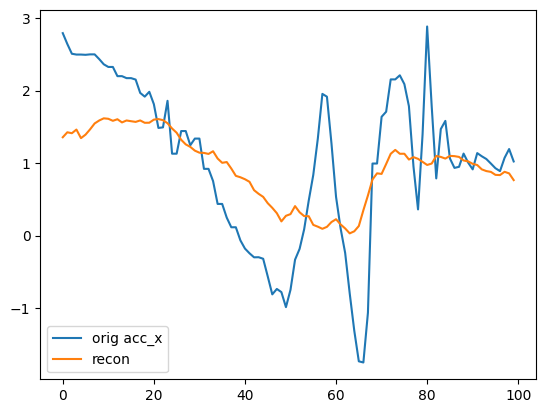

In [6]:
import matplotlib.pyplot as plt

i = 0
orig = X[i]
recon = autoencoder.predict(X[i:i+1])[0]

plt.plot(orig[:,0], label="orig acc_x")
plt.plot(recon[:,0], label="recon")
plt.legend()
plt.show()

In [7]:
import umap.umap_ as umap

latent_vectors = encoder.predict(X[:10000])  # sample pour vitesse

reducer = umap.UMAP(n_components=2)
embedding = reducer.fit_transform(latent_vectors)

c:\Users\Théo Lassale\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


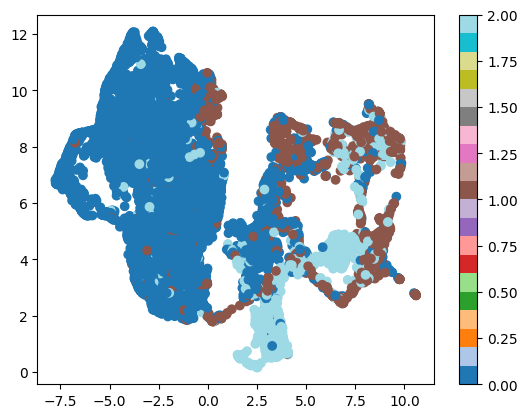

In [8]:
plt.scatter(embedding[:,0], embedding[:,1], c=labels[:10000], cmap='tab20')
plt.colorbar()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


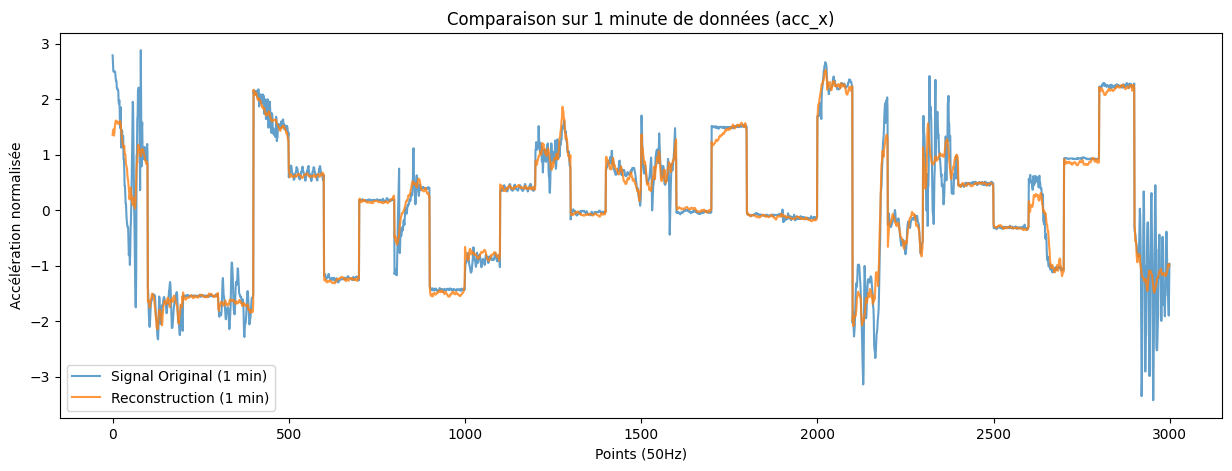

In [9]:
# 1. Sélectionner un segment de 30 fenêtres consécutives (environ 1 minute)
# On prend par exemple les 30 premières fenêtres du jeu de données X
n_windows = 30 
segment_orig = X[:n_windows] # Forme : (30, 100, 6)

# 2. Prédire la reconstruction pour tout ce bloc
segment_recon = autoencoder.predict(segment_orig) # Forme : (30, 100, 6)

# 3. "Aplatir" (Reshape) pour mettre les 3000 points à la suite
# On transforme (30, 100) en (3000,)
full_orig = segment_orig[:, :, 0].flatten() # On regarde l'acc_x (index 0)
full_recon = segment_recon[:, :, 0].flatten()

# 4. Affichage
plt.figure(figsize=(15, 5))
plt.plot(full_orig, label="Signal Original (1 min)", alpha=0.7)
plt.plot(full_recon, label="Reconstruction (1 min)", alpha=0.8)
plt.title("Comparaison sur 1 minute de données (acc_x)")
plt.xlabel("Points (50Hz)")
plt.ylabel("Accélération normalisée")
plt.legend()
plt.show()